In [64]:
from datasets import load_dataset, get_dataset_config_names


configs = get_dataset_config_names("JonathanZha/PADBen")
print(f"Available configurations ({len(configs)}):")
for name in configs:
    print(f"  - {name}")

preview_config = configs[0]
dataset_preview = load_dataset("JonathanZha/PADBen", preview_config)
print(f"\nPreview config: {preview_config}")
for key, value in dataset_preview["train"][:2].items():
    print(key, value)

idx [0, 1]
sentence_pair [['Souray married former WWE professional wrestler Barbara Blank , better known as Kelly Kelly in February 2016 . They have separated in October 2017 .', 'Souray wed former WWE professional wrestler Barbara Blank (aka Kelly Kelly) in February 2016, but they separated in October 2017.'], ["Moffitt stated that before individuals are tested for the gene's long or short forms, these findings must be confirmed in a new study.", 'Professor Moffitt said the results needed to be replicated before pursuing testing of individuals for the presence of the long or short versions of the gene .']]
label_pair [[0, 1], [1, 0]]
Available configurations (25):
  - sentence-pair-task1
  - sentence-pair-task2
  - sentence-pair-task3
  - sentence-pair-task4
  - sentence-pair-task5
  - exhaustive-task1
  - exhaustive-task2
  - exhaustive-task3
  - exhaustive-task4
  - exhaustive-task5
  - sampling-30-70-task1
  - sampling-30-70-task2
  - sampling-30-70-task3
  - sampling-30-70-task4
 

In [84]:
import pandas as pd


def build_padben_df_en(dataset):
    df = pd.DataFrame(dataset["train"])
    df["first_sentence"] = df["sentence_pair"].apply(lambda x: x[0])
    df["second_sentence"] = df["sentence_pair"].apply(lambda x: x[1])
    df["label_first"] = df["label_pair"].apply(lambda x: x[0])
    df["label_second"] = df["label_pair"].apply(lambda x: x[1])
    df1 = df[["idx", "first_sentence", "label_first"]].rename(columns={"first_sentence": "sentence", "label_first": "label"}).assign(order="first")
    df2 = df[["idx", "second_sentence", "label_second"]].rename(columns={"second_sentence": "sentence", "label_second": "label"}).assign(order="second")
    df_concat = pd.concat([df1, df2])
    return df_concat.rename(columns={"sentence": "text"})

In [42]:
%load_ext autoreload
%autoreload 2

import os
os.sys.path.append('../scripts/')
    
import pandas as pd
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx
import scipy.stats as ss
import pandas as pd
import numpy as np

from IPython.display import HTML, display_html
from phd_qwen_CUDA_clean import get_phd, load_roberta_model, load_qwen_model, get_embeds, preprocess_text
from lexicalrichness import LexicalRichness
from collections import Counter, defaultdict
from tqdm import tqdm
from phd_scale import set_all_seeds, load_qwen_model, get_embeds, get_answer,\
                      get_stats, get_embeds_tsne, get_mst_edge_lengths, calculate_df_edges, visualize_text
from phd_qwen_CUDA_clean import preprocess_text, pairwise_distances


set_all_seeds(42)
sns.set_style("darkgrid")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:

# df_en = pd.read_json("../PHD_experiments/notebooks/PHD_another/data/dev_intrinc_dimensions_roberta_gemma_qwen_phd__mle_twonn_tle.json")
tokenizer, model = load_qwen_model("google/gemma-4-E4B-it", device='cuda:3', token=token)
# df_en['gemini_tokenizer_len'] = df_en['text'].apply(lambda x: get_len_tokens(tokenizer, preprocess_text(x)))
# text = df_en['text'].values.tolist()[1]
# texts = df_en['text'].values.tolist()
# models = ['human', 'llama3-70b', 'gpt4o', 'gpt4']
# df_en = df_en.query("model in @models")
# df_en = df_en.query("gemini_tokenizer_len < 1024")

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

Модель загружена на: cuda:3


In [76]:
# df_en builds per config in the loop below.

In [ ]:
from tqdm import tqdm
from phd_scale import PHDimScale, get_embeds, plot_median_by_param_value
import pickle
import os


checkpoint_dir = "../data/tmp"
os.makedirs(checkpoint_dir, exist_ok=True)


def list_config_checkpoints(config_name):
    prefix = f"padben_{config_name}_step_"
    checkpoints = []
    for fname in os.listdir(checkpoint_dir):
        if fname.startswith(prefix) and fname.endswith(".pickle"):
            step_str = fname[len(prefix):-7]
            if step_str.isdigit():
                checkpoints.append((int(step_str), os.path.join(checkpoint_dir, fname)))
    checkpoints.sort(key=lambda x: x[0])
    return checkpoints


def trim_checkpoints(config_name, keep_last=2):
    checkpoints = list_config_checkpoints(config_name)
    to_delete = checkpoints[:-keep_last] if len(checkpoints) > keep_last else []
    for _, path in to_delete:
        os.remove(path)
        print(f"Removed old checkpoint: {path}")
    return list_config_checkpoints(config_name)


def clear_checkpoints(config_name):
    checkpoints = list_config_checkpoints(config_name)
    for _, path in checkpoints:
        os.remove(path)
        print(f"Removed checkpoint: {path}")
    return []


all_results = {}
for config_name in configs:
    output_path = f"../data/padben_{config_name}.pickle"
    trim_checkpoints(config_name, keep_last=2)

    if os.path.exists(output_path):
        print(f"Skip existing config: {config_name}")
        clear_checkpoints(config_name)
        all_results[config_name] = {"path": output_path, "status": "skipped_existing", "checkpoints": []}
        continue

    print(f"Processing config: {config_name}")
    dataset = load_dataset("JonathanZha/PADBen", config_name)
    df_en = build_padben_df_en(dataset)

    d_hat_stats_df_list = []
    d_energy_range_stats_df_list = []
    d_energy_upper_stats_df_list = []
    d_energy_lower_stats_df_list = []
    env_mean_by_n_list = []
    dfs_list = []

    texts = df_en["text"].values.tolist()
    indices = df_en.index.tolist()

    for index_num, (text, index) in enumerate(tqdm(zip(texts, indices), total=len(texts), desc=config_name)):
        embeds, tokens = get_embeds(text, tokenizer, model, returns_tokenized=True)
        phd_dim_scale = PHDimScale(n_fraction_list=[0.6, 0.7, 0.8, 0.9], p_range=0.5, replace=False, replicates=30)
        d_hat_stats_df, d_energy_range_stats_df, d_energy_upper_stats_df, d_energy_lower_stats_df = phd_dim_scale.calculate(
            embeds,
            index,
            tokens
        )

        dfs_list.append(phd_dim_scale.dfs)
        d_hat_stats_df_list.append(d_hat_stats_df)
        d_energy_range_stats_df_list.append(d_energy_range_stats_df)
        d_energy_upper_stats_df_list.append(d_energy_upper_stats_df)
        d_energy_lower_stats_df_list.append(d_energy_lower_stats_df)
        env_mean_by_n_list.append(phd_dim_scale.env_mean_by_n)

        if (index_num + 1) % 100 == 0:
            checkpoint_path = os.path.join(checkpoint_dir, f"padben_{config_name}_step_{index_num + 1}.pickle")
            with open(checkpoint_path, "wb") as fd:
                pickle.dump({
                    "config_name": config_name,
                    "df_en": df_en,
                    "d_hat_stats_df_list": d_hat_stats_df_list,
                    "d_energy_range_stats_df_list": d_energy_range_stats_df_list,
                    "d_energy_upper_stats_df_list": d_energy_upper_stats_df_list,
                    "d_energy_lower_stats_df_list": d_energy_lower_stats_df_list,
                    "dfs_list": dfs_list
                }, fd)
            trim_checkpoints(config_name, keep_last=2)

    with open(output_path, "wb") as fd:
        pickle.dump({
            "config_name": config_name,
            "df_en": df_en,
            "d_hat_stats_df_list": d_hat_stats_df_list,
            "d_energy_range_stats_df_list": d_energy_range_stats_df_list,
            "d_energy_upper_stats_df_list": d_energy_upper_stats_df_list,
            "d_energy_lower_stats_df_list": d_energy_lower_stats_df_list,
            "dfs_list": dfs_list
        }, fd)

    trim_checkpoints(config_name, keep_last=2)
    all_results[config_name] = {"path": output_path, "n_texts": len(texts), "status": "processed", "checkpoints": [p for _, p in list_config_checkpoints(config_name)]}

with open("../data/padben_all_configs.pickle", "wb") as fd:
    pickle.dump(all_results, fd)

print("Done. Processed or skipped configs:", len(all_results))

Skip existing config: sentence-pair-task1
Processing config: sentence-pair-task2


sentence-pair-task2:   0%|          | 100/32466 [01:19<8:15:28,  1.09it/s]

Removed old checkpoint: ../data/tmp/padben_sentence-pair-task2_step_100.pickle


sentence-pair-task2:   1%|          | 200/32466 [02:34<13:26:13,  1.50s/it]

Removed old checkpoint: ../data/tmp/padben_sentence-pair-task2_step_200.pickle


...

sentence-pair-task2:   9%|▉         | 2900/32466 [42:51<71:23:57,  8.69s/it]

Removed old checkpoint: ../data/tmp/padben_sentence-pair-task2_step_2700.pickle


sentence-pair-task2:   9%|▉         | 3000/32466 [44:33<74:11:59,  9.07s/it]

Removed old checkpoint: ../data/tmp/padben_sentence-pair-task2_step_2800.pickle


sentence-pair-task2:   9%|▉         | 3074/32466 [45:24<5:29:19,  1.49it/s] 

In [73]:
!mkdir ../data/figures

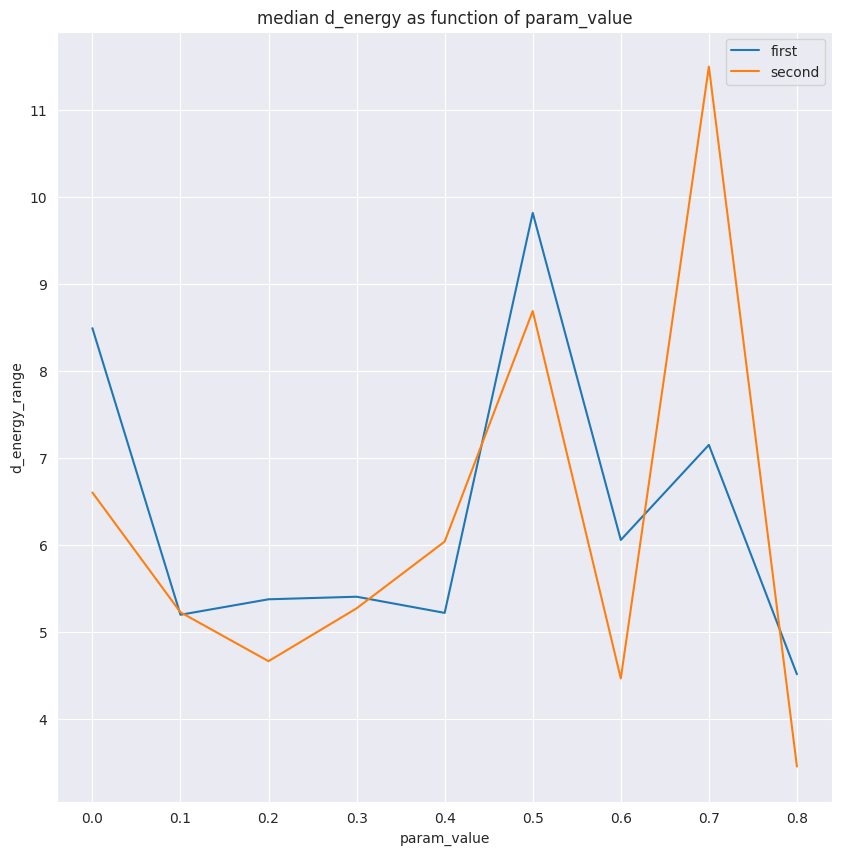

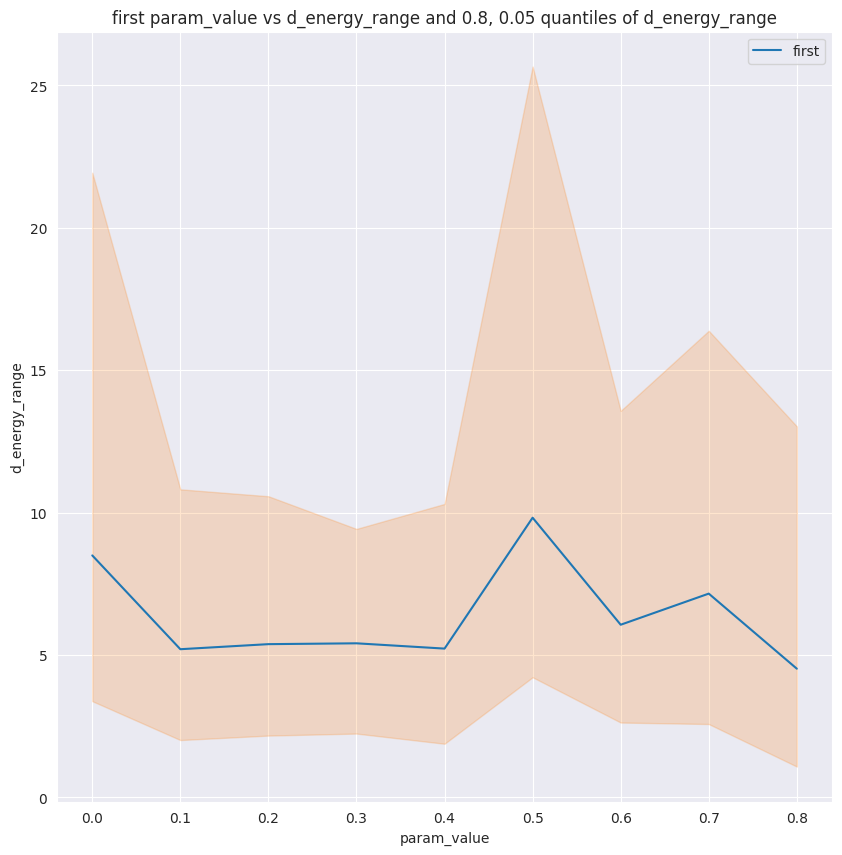

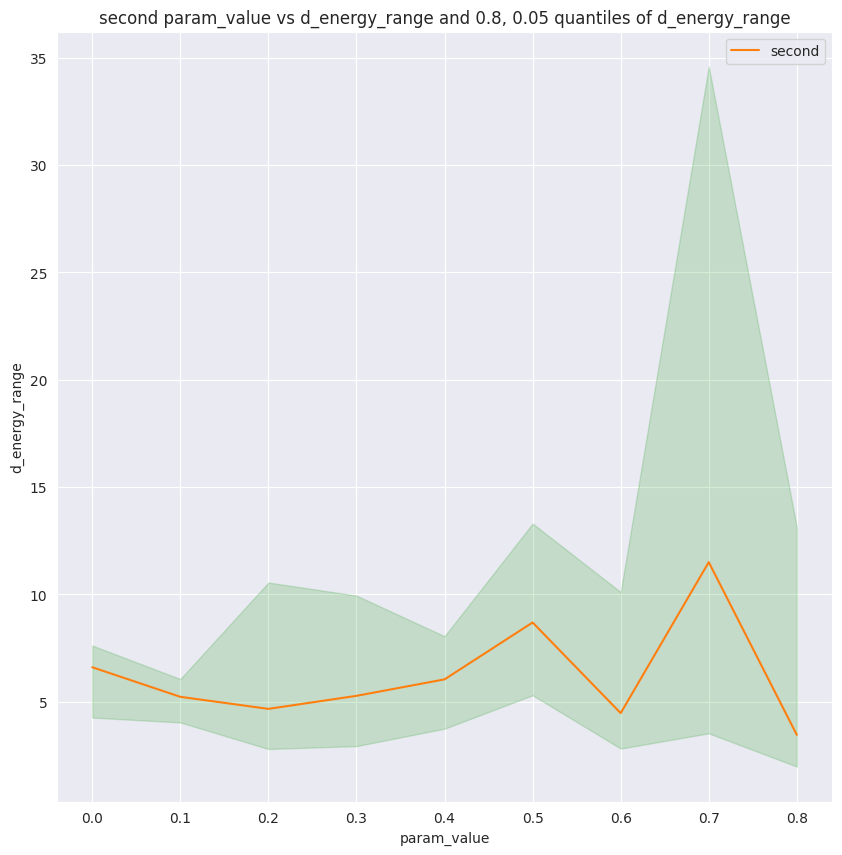

<Figure size 640x480 with 0 Axes>

In [81]:
# number_of_texts = 45000
number_of_texts = df_en.shape[0]
plot_median_by_param_value(
    df_en.rename(columns={'order': 'model'}),
    d_energy_range_stats_df_list,
    limit=number_of_texts,
    min_count_plot=number_of_texts * 0.032,
    obj_name='d_energy_range', 
    xlim=0.9,
    filename_save='../data/figures/d_energy_range'
)